# Study for the prediction of energy consumption per region at t+1

In [1]:

import os
import pandas as pd
from mix_energy import eco2mix_ingest as eco

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import  StandardScaler


from sklearn.model_selection import train_test_split

def build_df(dataset:str)->pd.DataFrame:
    print("Build a DataFrame instance from the dataset {}".format(dataset))
    
    dataset_file = os.path.join("../data/",f"{dataset}.csv")
    
    if not os.path.exists(dataset_file) :
        csv_content = eco.retrieve_csv(dataset_id=dataset)
        with open(dataset_file,"wb") as csv_file:
            csv_file.write(csv_content)
            
    df = pd.read_csv(dataset_file,sep=";")
    
    return df


# Energy Consumption prediction on a Real time dataset 

In [2]:
df = build_df("eco2mix-regional-tr")


print("Generic computational information extracted from the DataFrame")
df.describe()

Build a DataFrame instance from the dataset eco2mix-regional-tr
Generic computational information extracted from the DataFrame


,code_insee_region,consommation,thermique,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_68
count,69120.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,...,40040.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,68640.000000,0.0
mean,49.916667,4563.502885,158.761815,3852.502462,633.506352,260.269988,738.589423,-101.552783,93.005288,-1071.275830,...,75.634483,15.991419,29.794783,6.491531,10.198762,13.541450,69.383422,2.113255,52.738895,NaN
std,25.640188,2052.323722,210.497166,3893.460366,796.890151,547.733830,1173.534319,331.533909,58.351262,4542.560056,...,13.667133,17.173377,22.211751,13.792727,15.931591,17.934229,59.875568,1.169782,25.070750,NaN
min,11.000000,1398.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2358.000000,0.000000,-12263.000000,...,27.930000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,27.750000,2819.000000,28.000000,0.000000,93.000000,0.000000,16.000000,0.000000,45.000000,-4953.250000,...,64.760000,2.170000,9.920000,0.000000,0.000000,0.400000,29.080000,1.330000,37.040000,NaN
50%,48.000000,4355.000000,90.000000,2597.000000,350.000000,0.000000,125.000000,0.000000,91.000000,-737.000000,...,75.640000,9.780000,25.040000,0.000000,0.000000,4.860000,42.060000,1.790000,47.080000,NaN
75%,75.250000,5627.000000,204.000000,7739.000000,886.000000,248.000000,1074.000000,0.000000,104.000000,1932.000000,...,84.860000,24.932500,46.400000,6.420000,16.350000,21.830000,105.380000,2.350000,62.000000,NaN
max,93.000000,12172.000000,1882.000000,12243.000000,5476.000000,4596.000000,7706.000000,0.000000,274.000000,11650.000000,...,99.770000,106.010000,90.230000,154.210000,76.600000,110.510000,225.000000,7.390000,115.380000,NaN


In [3]:
print("Information on the structure of data inside the DataFrame")
df.info()

Information on the structure of data inside the DataFrame
<class 'pandas.DataFrame'>
RangeIndex: 69120 entries, 0 to 69119
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_insee_region    69120 non-null  int64  
 1   libelle_region       69120 non-null  str    
 2   nature               69120 non-null  str    
 3   date                 69120 non-null  str    
 4   heure                69120 non-null  str    
 5   date_heure           69120 non-null  str    
 6   consommation         68640 non-null  float64
 7   thermique            68640 non-null  float64
 8   nucleaire            68640 non-null  float64
 9   eolien               68640 non-null  float64
 10  solaire              68640 non-null  float64
 11  hydraulique          68640 non-null  float64
 12  pompage              68640 non-null  float64
 13  bioenergies          68640 non-null  float64
 14  ech_physiques        68640 non-null  fl

## Analysis of the data loaded in the dataset

Goal: Build a DataFrame ready to train a model to predict the electric consumption at a specific date and time

In [4]:
# List the columns
df.columns

Index(['code_insee_region', 'libelle_region', 'nature', 'date', 'heure',
       'date_heure', 'consommation', 'thermique', 'nucleaire', 'eolien',
       'solaire', 'hydraulique', 'pompage', 'bioenergies', 'ech_physiques',
       'stockage_batterie', 'destockage_batterie', 'tco_thermique',
       'tch_thermique', 'tco_nucleaire', 'tch_nucleaire', 'tco_eolien',
       'tch_eolien', 'tco_solaire', 'tch_solaire', 'tco_hydraulique',
       'tch_hydraulique', 'tco_bioenergies', 'tch_bioenergies', 'column_68'],
      dtype='str')

In [5]:
# We do not know what is the column represents so remove it
df = df.drop("column_68",axis=1)

# There is no use to keep both column. Only "code_insee_region" can be kept
df[["code_insee_region","libelle_region"]].groupby(by=["code_insee_region","libelle_region"]).count()


,
code_insee_region,libelle_region
11,Île-de-France
24,Centre-Val de Loire
27,Bourgogne-Franche-Comté
28,Normandie
32,Hauts-de-France
44,Grand Est
52,Pays de la Loire
53,Bretagne
75,Nouvelle-Aquitaine


<Axes: >

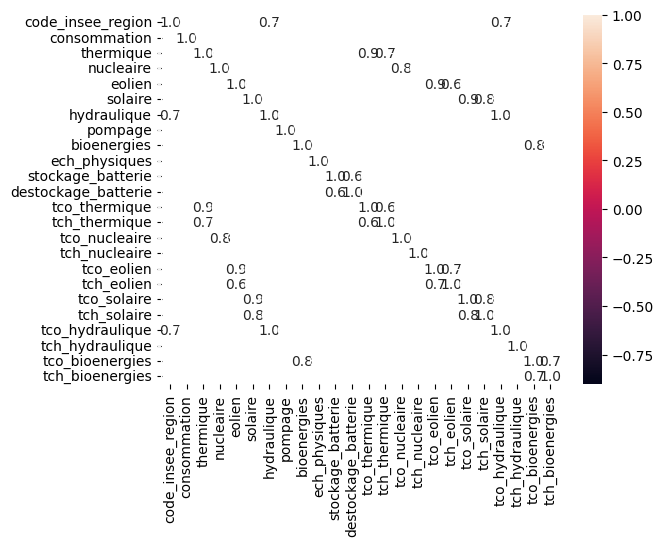

In [6]:
import seaborn as sb
df_num = df.select_dtypes(exclude=['str'])


sb.heatmap(df_num.corr(),annot=True, fmt=".1f",linewidths=15,)

There are a lot of correlated columns. It is normal as the value of many columns are the sum of those from other columns.
A notable correlation is that the column _"tco_hydraulique"_ is has a strong relationship to the _"code_insee_region"_ which could mean that the production of electricity using water engine is done in some specific region.
Not useful for our prediction but may be interesting to display


## Modifying the DataFrame

Only the INSEE region code, the date and time and the total of consumption fields are useful for our prediction.
For an obvious reason, the _"date_heure"_ is interpreted as a string type column and not a datetime type one. A string is not well formated for the models we want to use for our prediction

In [7]:
# By default the colum "date_heure" is interpreted as a string type and not a datetime
def change_date_heure(df_in:pd.DataFrame)->pd.DataFrame:
    return pd.to_datetime(df_in["date_heure"], format='%Y-%m-%dT%H:%M:%S+00:00', errors='coerce').dt.tz_localize(None)

In [8]:
# Keep only the useful columns and remove the NULL data
df_use = df[["code_insee_region","date_heure","consommation"]].dropna()

df_use["date_heure"] = change_date_heure(df_use)
df_use.info()

<class 'pandas.DataFrame'>
Index: 68640 entries, 0 to 69119
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   code_insee_region  68640 non-null  int64         
 1   date_heure         68640 non-null  datetime64[us]
 2   consommation       68640 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 2.1 MB


Our prediction is clearly a supervised regression problem.
However is not possible to predict the energy consumption at a given date with only the insee code and the date/time.
We will add a new column with the mean energy consumption until the given date

In [9]:
df_use = df_use.sort_values(by=["code_insee_region","date_heure"],ascending=[True,True],ignore_index=True)
#df_use.groupby(by=["code_insee_region","date_heure"])



In [10]:
# See if now we are able to retrieve all the entries before a given date for a specific region
date_before = pd.to_datetime('2026-03-30 00:00:00',unit="us")

df_res = df_use[(df_use.code_insee_region == 52) & (df_use.date_heure < date_before)]
df_res.head()


,code_insee_region,date_heure,consommation
34320,52,2026-01-31 23:00:00,3627.0
34321,52,2026-01-31 23:15:00,3684.0
34322,52,2026-01-31 23:30:00,3531.0
34323,52,2026-01-31 23:45:00,3464.0
34324,52,2026-02-01 00:00:00,3454.0


To strengthen the accurary of the prediction we add a column which contains at each line the mean of the consumption at time n-1

In [11]:
import numpy as np

def compute_prev_conso_mean(row):
    df_res = df_use[(df_use.code_insee_region == row["code_insee_region"]) & \
                        (df_use.date_heure < row["date_heure"])]
    
    mean_conso = df_res["consommation"].mean()
    
    if np.isnan(mean_conso):
        mean_conso = 0.0
    
    return mean_conso

df_use["prev_conso_mean"] = df_use.apply(compute_prev_conso_mean,axis=1)

df_use

,code_insee_region,date_heure,consommation,prev_conso_mean
0,11,2026-01-31 23:00:00,9106.0,0.000000
1,11,2026-01-31 23:15:00,9188.0,9106.000000
2,11,2026-01-31 23:30:00,8931.0,9147.000000
3,11,2026-01-31 23:45:00,8764.0,9075.000000
4,11,2026-02-01 00:00:00,8583.0,8997.250000
...,...,...,...,...
68635,93,2026-04-01 10:45:00,4713.0,4791.611199
68636,93,2026-04-01 11:00:00,4736.0,4791.597446
68637,93,2026-04-01 11:15:00,4748.0,4791.587721
68638,93,2026-04-01 11:30:00,4706.0,4791.580098


## Energy consumption prediction

### Preparing the date for the model

In [12]:
# The date_heure field will be hard to use in the training of a model
# So we split the value onto differents columns 

def split_datetime_col(df_in:pd.DataFrame):
    df_in["year"] = df_in["date_heure"].dt.year
    df_in["month"] = df_in["date_heure"].dt.month
    df_in["day"] = df_in["date_heure"].dt.day
    df_in["hour"] = df_in["date_heure"].dt.hour
    df_in["minute"] = df_in["date_heure"].dt.minute

In [13]:
split_datetime_col(df_use)

df_use.select_dtypes(include="number")

,code_insee_region,consommation,prev_conso_mean,year,month,day,hour,minute
0,11,9106.0,0.000000,2026,1,31,23,0
1,11,9188.0,9106.000000,2026,1,31,23,15
2,11,8931.0,9147.000000,2026,1,31,23,30
3,11,8764.0,9075.000000,2026,1,31,23,45
4,11,8583.0,8997.250000,2026,2,1,0,0
...,...,...,...,...,...,...,...,...
68635,93,4713.0,4791.611199,2026,4,1,10,45
68636,93,4736.0,4791.597446,2026,4,1,11,0
68637,93,4748.0,4791.587721,2026,4,1,11,15
68638,93,4706.0,4791.580098,2026,4,1,11,30


In [14]:
df_base = df_use.drop(columns=["consommation","prev_conso_mean","date_heure"])
to_predict = df_use["consommation"]

X_train, X_test, y_train, y_test = train_test_split(df_base,to_predict,random_state=42)



In [15]:
num_pipe = Pipeline(
    [("knn_imp", KNNImputer(n_neighbors=5))
     ,("scaler", StandardScaler())
      ])

preprocessor = ColumnTransformer(
    [("numeric",num_pipe, make_column_selector(dtype_include="number"))
      ]).set_output(transform="pandas")



In [16]:
def preprocess_data(preproc,X_train,X_test):
    preproc.fit(X_train)
    X_train_scaled = preproc.transform(X_train)
    X_test_scaled  = preproc.transform(X_test)
    return X_train_scaled,X_test_scaled

### Energy consumption prediction only with original data

In [17]:
logr_model = LinearRegression()

X_train_scaled,X_test_scaled = preprocess_data(preprocessor,X_train,X_test)

logr_model.fit(X_train_scaled,y_train) 
y_pred = logr_model.predict(X_test_scaled)

In [18]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,r2_score

def evaluate_model(y_test,y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f"Evaluation metrics: MAE={mae:.2f}, MSE={mse:.2f}, R2={r2:.2f}, MAPE={mape:.2%}")
    metrics = {"mae": mae, "mse": mse, "r2": r2, "mape": mape}
    return metrics

In [19]:
metrics = evaluate_model(y_test=y_test,y_pred=y_pred)

#y_pred
df_cmp = pd.DataFrame({"pred":y_pred,"test":y_test})
df_cmp


Evaluation metrics: MAE=1609.84, MSE=4105380.01, R2=0.03, MAPE=42.59%


,pred,test
47773,5142.544859,4501.0
19980,4221.716175,3563.0
15110,4081.028740,2165.0
29953,4566.333596,5459.0
9736,4284.731677,2398.0
...,...,...
8540,4186.818921,2542.0
1487,4418.071910,10944.0
66263,4915.672984,4839.0
31458,4507.973618,5394.0


As we can see the prediction is not quite good. The difference between the prediction and the real value is too big by moment ( 2428 MW predicted against 10944MW really consumed)

### Energy consumption prediction using additional computed data

Do the same thing but using the mean previous energy consumption

In [20]:
df_base = df_use.drop(columns=["consommation","date_heure"])
to_predict = df_use["consommation"]

X_train, X_test, y_train, y_test = train_test_split(df_base,to_predict,random_state=42)

X_train_scaled,X_test_scaled = preprocess_data(preprocessor,X_train,X_test)

logr_model2 = LinearRegression()

logr_model2.fit(X_train_scaled,y_train) 
y_pred = logr_model2.predict(X_test_scaled)

metrics2 = evaluate_model(y_test=y_test,y_pred=y_pred)

Evaluation metrics: MAE=419.45, MSE=323160.36, R2=0.92, MAPE=9.61%


In [21]:
df_tr_cmp = pd.DataFrame({"pred":y_pred,"test":y_test})
df_tr_cmp

,pred,test
47773,4891.660548,4501.0
19980,3052.895867,3563.0
15110,2132.195209,2165.0
29953,5282.135192,5459.0
9736,2171.161096,2398.0
...,...,...
8540,2065.734626,2542.0
1487,8957.749942,10944.0
66263,4751.759042,4839.0
31458,5273.422014,5394.0


The result is clearly better now. 
Maybe, it might be possible to get an even better result with another model.
Instead to compute the mean consumption value from the first entry until t-1, we should compute the mean consumption from the beginning of the day until t-1, the previous hour and the previous month.

In [25]:
import datetime

def compute_prev_conso_mean_h(row):
    current_dt = row["date_heure"]
    
    last_hour_dt = current_dt - pd.Timedelta(hours=1)
    
    df_res = df_use[(df_use.code_insee_region == row["code_insee_region"]) & \
                    ((df_use.date_heure < current_dt) & (df_use.date_heure >= last_hour_dt))]
    
    mean_conso = df_res["consommation"].mean()
    
    if np.isnan(mean_conso):
        mean_conso = 0.0
    
    return mean_conso


def compute_prev_conso_mean_m(row):
    current_dt = row["date_heure"]
    
    year = current_dt.year
    month = current_dt.month
    day = current_dt.day
    
    if month == 1:
        year -=1
        month = 12
    else:
        month -=1
        
    if month == 2 and day > 28:
        day = 28
    last_month_dt = datetime.datetime(year=year,month=month,day=day)
    
    df_res = df_use[(df_use.code_insee_region == row["code_insee_region"]) & \
                    ((df_use.date_heure < current_dt) & (df_use.date_heure >= last_month_dt))]
    
    mean_conso = df_res["consommation"].mean()
    
    if np.isnan(mean_conso):
        mean_conso = 0.0
    
    return mean_conso

df_use["prev_conso_mean_h"] = df_use.apply(compute_prev_conso_mean_h,axis=1)


df_use

,code_insee_region,date_heure,consommation,prev_conso_mean,year,month,day,hour,minute,prev_conso_mean_h
0,11,2026-01-31 23:00:00,9106.0,0.000000,2026,1,31,23,0,0.00
1,11,2026-01-31 23:15:00,9188.0,9106.000000,2026,1,31,23,15,9106.00
2,11,2026-01-31 23:30:00,8931.0,9147.000000,2026,1,31,23,30,9147.00
3,11,2026-01-31 23:45:00,8764.0,9075.000000,2026,1,31,23,45,9075.00
4,11,2026-02-01 00:00:00,8583.0,8997.250000,2026,2,1,0,0,8997.25
...,...,...,...,...,...,...,...,...,...,...
68635,93,2026-04-01 10:45:00,4713.0,4791.611199,2026,4,1,10,45,4830.50
68636,93,2026-04-01 11:00:00,4736.0,4791.597446,2026,4,1,11,0,4808.25
68637,93,2026-04-01 11:15:00,4748.0,4791.587721,2026,4,1,11,15,4775.00
68638,93,2026-04-01 11:30:00,4706.0,4791.580098,2026,4,1,11,30,4752.50


In [26]:
df_use["prev_conso_mean_m"] = df_use.apply(compute_prev_conso_mean_m,axis=1)

df_use

,code_insee_region,date_heure,consommation,prev_conso_mean,year,month,day,hour,minute,prev_conso_mean_h,prev_conso_mean_m
0,11,2026-01-31 23:00:00,9106.0,0.000000,2026,1,31,23,0,0.00,0.000000
1,11,2026-01-31 23:15:00,9188.0,9106.000000,2026,1,31,23,15,9106.00,9106.000000
2,11,2026-01-31 23:30:00,8931.0,9147.000000,2026,1,31,23,30,9147.00,9147.000000
3,11,2026-01-31 23:45:00,8764.0,9075.000000,2026,1,31,23,45,9075.00,9075.000000
4,11,2026-02-01 00:00:00,8583.0,8997.250000,2026,2,1,0,0,8997.25,8997.250000
...,...,...,...,...,...,...,...,...,...,...,...
68635,93,2026-04-01 10:45:00,4713.0,4791.611199,2026,4,1,10,45,4830.50,4601.799206
68636,93,2026-04-01 11:00:00,4736.0,4791.597446,2026,4,1,11,0,4808.25,4601.835979
68637,93,2026-04-01 11:15:00,4748.0,4791.587721,2026,4,1,11,15,4775.00,4601.880331
68638,93,2026-04-01 11:30:00,4706.0,4791.580098,2026,4,1,11,30,4752.50,4601.928619


In [27]:
# year is not useful because in tr dataset there is only one year
df_base = df_use.drop(columns=["consommation","date_heure","year"])
to_predict = df_use["consommation"]

X_train, X_test, y_train, y_test = train_test_split(df_base,to_predict,random_state=42)

X_train_scaled,X_test_scaled = preprocess_data(preprocessor,X_train,X_test)

lnr_model3 = LinearRegression()

lnr_model3.fit(X_train_scaled,y_train) 
y_pred = lnr_model3.predict(X_test_scaled)

metrics3 = evaluate_model(y_test=y_test,y_pred=y_pred)

Evaluation metrics: MAE=112.28, MSE=27442.55, R2=0.99, MAPE=2.60%


In [28]:
df_tr_cmp = pd.DataFrame({"pred":y_pred,"test":y_test})
df_tr_cmp

,pred,test
47773,4531.034232,4501.0
19980,3562.413010,3563.0
15110,2150.460501,2165.0
29953,5328.426071,5459.0
9736,2394.446127,2398.0
...,...,...
8540,2557.558433,2542.0
1487,10991.508834,10944.0
66263,4863.989508,4839.0
31458,5061.435373,5394.0


# Energy consumption prediction on consolidated dataset

In [29]:
df_conso = build_df("eco2mix-national-cons-def")

df_conso.head()

Build a DataFrame instance from the dataset eco2mix-national-cons-def


/tmp/ipykernel_7506/883395013.py:27: DtypeWarning: Columns (0: ech_comm_allemagne_belgique, 1: gaz_cogen) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_file,sep=";")


,perimetre,nature,date,heure,date_heure,consommation,prevision_j1,prevision_j,fioul,charbon,...,gaz_tac,gaz_cogen,gaz_ccg,gaz_autres,hydraulique_fil_eau_eclusee,hydraulique_lacs,hydraulique_step_turbinage,bioenergies_dechets,bioenergies_biomasse,bioenergies_biogaz
0,France,Données définitives,2023-01-11,10:30,2023-01-11T09:30:00+00:00,63778.0,63900,63100,86.0,22.0,...,94.0,839.0,1006.0,1234.0,6169.0,2048.0,2448.0,482.0,311.0,317.0
1,France,Données définitives,2023-01-11,12:00,2023-01-11T11:00:00+00:00,64049.0,64200,63100,85.0,23.0,...,96.0,841.0,955.0,1236.0,5820.0,1472.0,2401.0,477.0,312.0,321.0
2,France,Données définitives,2023-01-11,13:30,2023-01-11T12:30:00+00:00,60786.0,61000,59500,85.0,23.0,...,96.0,841.0,713.0,1255.0,5385.0,913.0,626.0,482.0,324.0,326.0
3,France,Données définitives,2023-01-11,15:15,2023-01-11T14:15:00+00:00,NaN,60750,58600,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2023-01-11,16:15,2023-01-11T15:15:00+00:00,NaN,59600,57650,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df_conso.info()

<class 'pandas.DataFrame'>
RangeIndex: 493920 entries, 0 to 493919
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   perimetre                    493920 non-null  str    
 1   nature                       493920 non-null  str    
 2   date                         493920 non-null  str    
 3   heure                        493920 non-null  str    
 4   date_heure                   493920 non-null  str    
 5   consommation                 246960 non-null  float64
 6   prevision_j1                 493920 non-null  int64  
 7   prevision_j                  493920 non-null  int64  
 8   fioul                        246960 non-null  float64
 9   charbon                      246960 non-null  float64
 10  gaz                          246960 non-null  float64
 11  nucleaire                    246960 non-null  float64
 12  eolien                       246960 non-null  float64
 13  solaire   

In [31]:
df_conso.describe()

,consommation,prevision_j1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,...,fioul_autres,gaz_tac,gaz_ccg,gaz_autres,hydraulique_fil_eau_eclusee,hydraulique_lacs,hydraulique_step_turbinage,bioenergies_dechets,bioenergies_biomasse,bioenergies_biogaz
count,246960.000000,493920.000000,493920.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,...,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000
mean,53084.492347,52611.995752,52542.224810,235.592687,720.638306,3252.355637,42456.792898,3600.369695,1513.654280,7154.895181,...,73.689003,44.850897,1963.638294,231.553252,4627.230319,1848.420413,674.725595,486.531856,298.790733,277.485547
std,11780.297564,11771.763721,11740.470064,266.612984,1048.512664,2467.530793,7735.669773,3249.308564,2674.203452,2824.596832,...,167.998415,93.895940,1806.755436,383.805309,1525.688273,1142.891634,771.147460,59.194505,87.323709,64.764574
min,29124.000000,27500.000000,0.000000,18.000000,-133.000000,196.000000,19164.000000,21.000000,-23.000000,1387.000000,...,-13.000000,-10.000000,-18.000000,3.000000,1209.000000,46.000000,-2.000000,229.000000,111.000000,111.000000
25%,44182.000000,43700.000000,43700.000000,84.000000,15.000000,933.000000,37844.000000,1314.000000,0.000000,5001.000000,...,5.000000,0.000000,226.000000,49.000000,3356.000000,982.000000,11.000000,449.000000,246.000000,219.000000
50%,51290.500000,50800.000000,50800.000000,134.000000,59.000000,2754.000000,41997.000000,2511.000000,22.000000,6910.000000,...,18.000000,5.000000,1372.000000,71.000000,4745.000000,1632.000000,379.000000,491.000000,296.000000,300.000000
75%,60981.000000,60450.000000,60300.000000,315.000000,1104.000000,4851.000000,47501.000000,4809.000000,2044.000000,9019.250000,...,44.000000,41.000000,3515.000000,117.000000,5854.000000,2472.000000,1083.000000,529.000000,355.000000,334.000000
max,102098.000000,101000.000000,102700.000000,5926.000000,6265.000000,10611.000000,61712.000000,20131.000000,21627.000000,17947.000000,...,3576.000000,790.000000,6580.000000,2530.000000,8430.000000,7211.000000,4293.000000,2655.000000,661.000000,448.000000


## Prepare the dataset

In [32]:
df_conso.columns

Index(['perimetre', 'nature', 'date', 'heure', 'date_heure', 'consommation',
       'prevision_j1', 'prevision_j', 'fioul', 'charbon', 'gaz', 'nucleaire',
       'eolien', 'solaire', 'hydraulique', 'pompage', 'bioenergies',
       'ech_physiques', 'taux_co2', 'ech_comm_angleterre', 'ech_comm_espagne',
       'ech_comm_italie', 'ech_comm_suisse', 'ech_comm_allemagne_belgique',
       'fioul_tac', 'fioul_cogen', 'fioul_autres', 'gaz_tac', 'gaz_cogen',
       'gaz_ccg', 'gaz_autres', 'hydraulique_fil_eau_eclusee',
       'hydraulique_lacs', 'hydraulique_step_turbinage', 'bioenergies_dechets',
       'bioenergies_biomasse', 'bioenergies_biogaz'],
      dtype='str')

In [33]:
df_conso = df_conso[["date_heure","consommation","prevision_j1","prevision_j"]].dropna()

df_conso["date_heure"] = change_date_heure(df_conso)
split_datetime_col(df_conso)

df_conso.select_dtypes(include="number")

,consommation,prevision_j1,prevision_j,year,month,day,hour,minute
0,63778.0,63900,63100,2023,1,11,9,30
1,64049.0,64200,63100,2023,1,11,11,0
2,60786.0,61000,59500,2023,1,11,12,30
6,60217.0,61600,59900,2023,1,11,16,30
8,66042.0,66600,65100,2023,1,11,18,0
...,...,...,...,...,...,...,...,...
493912,45151.0,45300,44600,2024,7,26,20,30
493915,43730.0,41500,42200,2024,7,26,22,30
493916,34925.0,33900,34400,2024,7,27,2,0
493918,34508.0,34100,34600,2024,7,27,5,0


In [34]:
df_conso.sort_values(by=["date_heure"],ascending=[True],ignore_index=True)

,date_heure,consommation,prevision_j1,prevision_j,year,month,day,hour,minute
0,2011-12-31 23:00:00,58315.0,58200,58200,2011,12,31,23,0
1,2011-12-31 23:30:00,58315.0,57200,56900,2011,12,31,23,30
2,2012-01-01 00:00:00,56231.0,55200,55100,2012,1,1,0,0
3,2012-01-01 00:30:00,56075.0,56000,55400,2012,1,1,0,30
4,2012-01-01 01:00:00,55532.0,56000,55000,2012,1,1,1,0
...,...,...,...,...,...,...,...,...,...
246955,2026-01-31 20:30:00,59856.0,59100,59100,2026,1,31,20,30
246956,2026-01-31 21:00:00,58718.0,58200,58200,2026,1,31,21,0
246957,2026-01-31 21:30:00,59389.0,60200,60100,2026,1,31,21,30
246958,2026-01-31 22:00:00,60611.0,61700,61500,2026,1,31,22,0


In [35]:
df_conso.info()

<class 'pandas.DataFrame'>
Index: 246960 entries, 0 to 493919
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_heure    246960 non-null  datetime64[us]
 1   consommation  246960 non-null  float64       
 2   prevision_j1  246960 non-null  int64         
 3   prevision_j   246960 non-null  int64         
 4   year          246960 non-null  int32         
 5   month         246960 non-null  int32         
 6   day           246960 non-null  int32         
 7   hour          246960 non-null  int32         
 8   minute        246960 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(5), int64(2)
memory usage: 14.1 MB


## Predict of the energy consumption

### Without prevision values

In [37]:
df_cbase = df_conso.drop(columns=["date_heure","consommation","prevision_j1","prevision_j"])
df_cprev = df_conso["prevision_j"]
df_cexp = df_conso["consommation"]

#X_train, X_test, y_train, y_test = train_test_split(df_cbase,df_cexp,train_size=40000, test_size=20000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_cbase,df_cexp, random_state=42)

X_train_scaled,X_test_scaled = preprocess_data(preprocessor,X_train,X_test)



In [38]:
linr_model_conso = LinearRegression(n_jobs=2)

linr_model_conso.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",2
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = linr_model_conso.predict(X_test_scaled)

metrics2 = evaluate_model(y_test=y_test,y_pred=y_pred)

Evaluation metrics: MAE=9113.17, MSE=124602687.38, R2=0.11, MAPE=17.75%


Very bad result. As we have seen with the previous dataset, without additional information it is not possible to predict a value

In [40]:
df_conso_cmp = pd.DataFrame({"estimated":y_pred,"real":y_test}) #"pred_j":df_cprev.values})
df_conso_cmp

,estimated,real
181777,53238.434487,68870.0
251388,53760.041228,57552.0
153660,58940.095210,89105.0
438104,51818.498926,54790.0
146428,55819.636283,48007.0
...,...,...
490676,48869.537370,49794.0
231535,50574.177328,47571.0
450323,52084.406193,44692.0
189396,56059.284471,41334.0


### With prevision j-1

In [42]:
df_cbase = df_conso.drop(columns=["date_heure","consommation","prevision_j"])

X_train, X_test, y_train, y_test = train_test_split(df_cbase,df_cexp, random_state=42)

X_train_scaled,X_test_scaled = preprocess_data(preprocessor,X_train,X_test)

linr_model_conso2 = LinearRegression(n_jobs=2)

linr_model_conso2.fit(X_train_scaled,y_train)

y_pred = linr_model_conso2.predict(X_test_scaled)

metrics3 = evaluate_model(y_test=y_test,y_pred=y_pred)

Evaluation metrics: MAE=853.26, MSE=1274806.57, R2=0.99, MAPE=1.62%


In [50]:
df_cprev.values[0:]

array([63100, 63100, 59500, ..., 34400, 34600, 35200], shape=(246960,))

In [53]:
df_conso_cmp = pd.DataFrame({"estimated":y_pred,"real":y_test})
df_conso_cmp

,estimated,real
181777,67847.880431,68870.0
251388,57239.906572,57552.0
153660,88148.971125,89105.0
438104,53561.423218,54790.0
146428,48262.995244,48007.0
...,...,...
490676,50940.809104,49794.0
231535,46704.597873,47571.0
450323,44169.650045,44692.0
189396,42795.910828,41334.0
